# Notebook 06 — Task Arithmetic with MobileNetV3 + EuroSAT

**Linear Mode Connectivity, Model Alignment and Functional Repair**
*Deep Learning & Applied AI — Sapienza Università di Roma, 2024/2025*

---

## Overview

This notebook closes the project with a **practical application** of the
machinery built in NB02–05.

* Model: **MobileNetV3-small** (inverted residuals + Squeeze-and-Excite),
  ImageNet-pretrained, head replaced.  This is *not* a ResNet variant —
  consistent with the course-originality constraint.
* Dataset: **EuroSAT** (Helber et al., 2019), 27 K Sentinel-2 satellite
  patches over 10 land-use classes.
* Two **disjoint binary sub-tasks** defined from the 10 classes:
  * $T_1$ — *vegetation vs built*: {Forest, Pasture, HerbaceousVegetation}
    vs {Residential, Industrial, Highway}
  * $T_2$ — *water vs land*: {River, SeaLake} vs {AnnualCrop,
    PermanentCrop}
* Each sub-task is solved by fine-tuning the pretrained backbone.

Following Ilharco et al. (2023), the **task vector** for sub-task $i$ is

$$
\tau_i = \theta_{T_i} - \theta_{\text{base}},
$$

and **task arithmetic** combines them into a single model:

$$
\theta_{\text{combined}} = \theta_{\text{base}} + \sum_i \lambda_i \tau_i .
$$

We compare four merge strategies on the joint $T_1 \cup T_2$ test:

1. **Naive task arithmetic** — sum of task vectors with $\lambda_i = 1$.
2. **Coefficient-tuned task arithmetic** — sweep $\lambda \in [0.2, 1.5]$ for a
   common scaling factor and pick the best.
3. **TIES-Merging** (Yadav et al., 2023) over $\{\theta_{T_1}, \theta_{T_2}\}$.
4. **Single-task baselines** — using only $\theta_{T_1}$ or $\theta_{T_2}$.

### References
* Helber et al. (2019) — *EuroSAT.*  JSTARS.
* Howard et al. (2019) — *Searching for MobileNetV3.*  ICCV.
* Ilharco et al. (2023) — *Editing models with task arithmetic.*  ICLR.
* Yadav et al. (2023) — *TIES-Merging.*  NeurIPS.


## 1. Setup

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import copy
import json
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset

from src.utils import set_seed, get_device
from src.models import get_mobilenetv3
from src.training import evaluate
from src.multimodel import naive_mean_merge, ties_merge

set_seed(0)
device = get_device()
print(f"Device: {device}")

os.makedirs("../checkpoints", exist_ok=True)
os.makedirs("../figures", exist_ok=True)
os.makedirs("../results", exist_ok=True)

/Users/carlos/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps


---
## 2. EuroSAT — Build the Two Sub-Tasks

EuroSAT's 10 classes (in torchvision ordering):

| Idx | Name |
|---|---|
| 0 | AnnualCrop |
| 1 | Forest |
| 2 | HerbaceousVegetation |
| 3 | Highway |
| 4 | Industrial |
| 5 | Pasture |
| 6 | PermanentCrop |
| 7 | Residential |
| 8 | River |
| 9 | SeaLake |

We define two **binary sub-tasks** by mapping classes to {0, 1}:

* $T_1$ (vegetation vs built): pos = {1, 2, 5}, neg = {3, 4, 7}
* $T_2$ (water vs land): pos = {8, 9}, neg = {0, 6}

Each sub-task uses only the classes listed above (other classes are
filtered out).

In [3]:
import torchvision
import torchvision.transforms as T

EUROSAT_MEAN = (0.3444, 0.3803, 0.4078)
EUROSAT_STD  = (0.2035, 0.1367, 0.1156)

train_tf = T.Compose([
    T.Resize(64),
    T.RandomCrop(64, padding=8),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(EUROSAT_MEAN, EUROSAT_STD),
])
test_tf = T.Compose([
    T.Resize(64),
    T.ToTensor(),
    T.Normalize(EUROSAT_MEAN, EUROSAT_STD),
])

DATA_ROOT = "./data"
os.makedirs(DATA_ROOT, exist_ok=True)

full_train = torchvision.datasets.EuroSAT(
    root=DATA_ROOT, download=True, transform=train_tf)
full_test  = torchvision.datasets.EuroSAT(
    root=DATA_ROOT, download=False, transform=test_tf)

# 80/20 split (deterministic)
n = len(full_train)
g = torch.Generator().manual_seed(42)
perm = torch.randperm(n, generator=g).tolist()
split = int(0.8 * n)
train_idx = perm[:split]
test_idx  = perm[split:]

print(f"EuroSAT total = {n} | train = {len(train_idx)} | test = {len(test_idx)}")

EuroSAT total = 27000 | train = 21600 | test = 5400


In [4]:
# Task definitions
TASK_DEFS = {
    "T1_veg_vs_built": {"pos": {1, 2, 5}, "neg": {3, 4, 7}},
    "T2_water_vs_land": {"pos": {8, 9},   "neg": {0, 6}},
}


class BinarySubsetEuroSAT(torch.utils.data.Dataset):
    """Wraps EuroSAT, keeps only classes in (pos ∪ neg), returns binary label."""
    def __init__(self, base, idx, pos, neg):
        self.base = base
        self.pos = set(pos)
        self.neg = set(neg)
        keep = self.pos | self.neg
        # filter indices
        self.idx = [i for i in idx if base.samples[i][1] in keep]

    def __len__(self):
        return len(self.idx)

    def __getitem__(self, k):
        i = self.idx[k]
        x, y = self.base[i]
        new_y = 1 if y in self.pos else 0
        return x, new_y


def make_loaders(task_name, batch_size=64):
    pos = TASK_DEFS[task_name]["pos"]
    neg = TASK_DEFS[task_name]["neg"]
    tr = BinarySubsetEuroSAT(full_train, train_idx, pos, neg)
    te = BinarySubsetEuroSAT(full_test,  test_idx,  pos, neg)
    return (
        DataLoader(tr, batch_size=batch_size, shuffle=True,  num_workers=0),
        DataLoader(te, batch_size=batch_size, shuffle=False, num_workers=0),
    )


loaders = {name: make_loaders(name) for name in TASK_DEFS}
for name, (ltr, lte) in loaders.items():
    print(f"  {name:<22} train={len(ltr.dataset):>5}  test={len(lte.dataset):>5}")

  T1_veg_vs_built        train=12795  test= 3205
  T2_water_vs_land       train= 8805  test= 2195


---
## 3. Build the Pretrained Backbone (base model)

`get_mobilenetv3(num_classes=2, pretrained=True)` returns a MobileNetV3-small
with ImageNet-pretrained features and a fresh 2-class head.

In [5]:
def build_model(num_classes=2, pretrained=True):
    model = get_mobilenetv3(num_classes=num_classes, pretrained=pretrained)
    return model.to(device)


# theta_base is the *pretrained* backbone with a fresh, randomly initialized head.
set_seed(0)
base_model = build_model(num_classes=2, pretrained=True)
sd_base = {k: v.detach().cpu().clone() for k, v in base_model.state_dict().items()}
print(f"Base model — total params: {sum(p.numel() for p in base_model.parameters()) / 1e6:.2f} M")

Base model — total params: 1.52 M


---
## 4. Fine-tune $\theta_{T_1}$ and $\theta_{T_2}$

In [6]:
def fine_tune(model, train_loader, test_loader, epochs=3, lr=1e-3):
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    crit = nn.CrossEntropyLoss()
    for ep in range(epochs):
        running = 0.0
        n_seen = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            out = model(x)
            loss = crit(out, y)
            loss.backward()
            opt.step()
            running += loss.item() * x.size(0)
            n_seen += x.size(0)
        train_loss = running / max(n_seen, 1)
        te_loss, te_acc = evaluate(model, test_loader, crit, device)
        print(f"   epoch {ep+1:>2}/{epochs}  train_loss={train_loss:.4f}  "
              f"test_loss={te_loss:.4f}  test_acc={te_acc:.4f}")
    return model

In [7]:
task_sds = {}
task_metrics = {}

for name in TASK_DEFS:
    ckpt = f"../checkpoints/mobilenetv3_eurosat_{name}.pt"
    if os.path.exists(ckpt):
        print(f"Loading cached fine-tune for {name}: {ckpt}")
        task_sds[name] = torch.load(ckpt, map_location="cpu")
    else:
        print(f"\nFine-tuning {name} ...")
        set_seed(42)
        m = build_model(num_classes=2, pretrained=True)
        m.load_state_dict({k: v.to(device) for k, v in sd_base.items()})
        tr, te = loaders[name]
        m = fine_tune(m, tr, te, epochs=3, lr=1e-3)
        task_sds[name] = {k: v.detach().cpu().clone()
                          for k, v in m.state_dict().items()}
        torch.save(task_sds[name], ckpt)

    # Per-task accuracy
    m_eval = build_model(num_classes=2, pretrained=False)
    m_eval.load_state_dict({k: v.to(device) for k, v in task_sds[name].items()})
    _, te = loaders[name]
    crit = nn.CrossEntropyLoss()
    loss, acc = evaluate(m_eval, te, crit, device)
    task_metrics[name] = {"loss": float(loss), "acc": float(acc)}
    print(f"  ✓ {name}  test_loss={loss:.4f}  test_acc={acc:.4f}")


Fine-tuning T1_veg_vs_built ...
   epoch  1/3  train_loss=0.1195  test_loss=0.1014  test_acc=0.9654
   epoch  2/3  train_loss=0.0622  test_loss=0.0908  test_acc=0.9725
   epoch  3/3  train_loss=0.0346  test_loss=0.0263  test_acc=0.9916
  ✓ T1_veg_vs_built  test_loss=0.0263  test_acc=0.9916

Fine-tuning T2_water_vs_land ...
   epoch  1/3  train_loss=0.1459  test_loss=0.1344  test_acc=0.9590
   epoch  2/3  train_loss=0.1003  test_loss=0.0489  test_acc=0.9831
   epoch  3/3  train_loss=0.0516  test_loss=0.0355  test_acc=0.9872
  ✓ T2_water_vs_land  test_loss=0.0355  test_acc=0.9872


---
## 5. Build Task Vectors

$$\tau_i = \theta_{T_i} - \theta_{\text{base}}$$

Integer parameters (e.g. BN's `num_batches_tracked`) are not floats — we
copy them from $\theta_{\text{base}}$ verbatim.

In [8]:
def task_vector(sd_task, sd_base):
    tv = {}
    for k, v in sd_task.items():
        if v.dtype.is_floating_point and k in sd_base:
            tv[k] = v.float() - sd_base[k].float()
        else:
            tv[k] = v.clone()
    return tv

tau = {name: task_vector(task_sds[name], sd_base) for name in TASK_DEFS}
print("Built task vectors:", list(tau.keys()))

Built task vectors: ['T1_veg_vs_built', 'T2_water_vs_land']


---
## 6. Joint Evaluation Set ($T_1 \cup T_2$)

For task arithmetic we need a *single* binary problem to evaluate against.
We define $T_1 \cup T_2$ as: positive ↦ (vegetation or water);
negative ↦ (built or non-water land).  This is the closure under
*disjoint* binary unions and lets us evaluate the combined model with a
single 2-class head.

In [9]:
POS_UNION = TASK_DEFS["T1_veg_vs_built"]["pos"] | TASK_DEFS["T2_water_vs_land"]["pos"]
NEG_UNION = TASK_DEFS["T1_veg_vs_built"]["neg"] | TASK_DEFS["T2_water_vs_land"]["neg"]

ds_union_train = BinarySubsetEuroSAT(full_train, train_idx, POS_UNION, NEG_UNION)
ds_union_test  = BinarySubsetEuroSAT(full_test,  test_idx,  POS_UNION, NEG_UNION)

union_train = DataLoader(ds_union_train, batch_size=64, shuffle=True,  num_workers=0)
union_test  = DataLoader(ds_union_test,  batch_size=64, shuffle=False, num_workers=0)

print(f"Joint task (T1 ∪ T2):  train={len(ds_union_train)}  test={len(ds_union_test)}")
print(f"  positive classes: {sorted(POS_UNION)}")
print(f"  negative classes: {sorted(NEG_UNION)}")

Joint task (T1 ∪ T2):  train=21600  test=5400
  positive classes: [1, 2, 5, 8, 9]
  negative classes: [0, 3, 4, 6, 7]


---
## 7. Apply Task Arithmetic and Compare Methods

In [10]:
def apply_task_vectors(sd_base, tvs, lambdas):
    out = {}
    for k, v in sd_base.items():
        if v.dtype.is_floating_point:
            acc = v.float().clone()
            for lam, tv in zip(lambdas, tvs):
                acc = acc + lam * tv[k]
            out[k] = acc
        else:
            out[k] = v.clone()
    return out


def evaluate_sd(sd, loader):
    m = build_model(num_classes=2, pretrained=False)
    m.load_state_dict({k: v.to(device) for k, v in sd.items()})
    crit = nn.CrossEntropyLoss()
    return evaluate(m, loader, crit, device)


tvs = [tau["T1_veg_vs_built"], tau["T2_water_vs_land"]]
results_arith = {}

# (a) Each individual task model on the JOINT test
print("Per-task models evaluated on the joint task:")
for name in TASK_DEFS:
    loss, acc = evaluate_sd(task_sds[name], union_test)
    results_arith[name + "_only"] = {"loss": float(loss), "acc": float(acc)}
    print(f"  {name:<22}  joint_loss={loss:.4f}  joint_acc={acc:.4f}")

# (b) Naive task arithmetic (lambda=1)
sd_naive = apply_task_vectors(sd_base, tvs, [1.0, 1.0])
loss, acc = evaluate_sd(sd_naive, union_test)
results_arith["task_arith_naive"] = {"loss": float(loss), "acc": float(acc)}
print(f"\n  naive task arithmetic (λ=1) joint_acc={acc:.4f}  loss={loss:.4f}")

# (c) Coefficient-tuned task arithmetic
print("\nCoefficient sweep (lambda applied to both task vectors equally):")
lambda_grid = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.5]
sweep = []
for lam in lambda_grid:
    sd_lam = apply_task_vectors(sd_base, tvs, [lam, lam])
    loss, acc = evaluate_sd(sd_lam, union_test)
    sweep.append({"lambda": lam, "loss": float(loss), "acc": float(acc)})
    print(f"  λ={lam:>4.2f}  joint_acc={acc:.4f}  loss={loss:.4f}")
best = max(sweep, key=lambda r: r["acc"])
results_arith["task_arith_best_lambda"] = best
print(f"  ➜ best λ = {best['lambda']}  joint_acc = {best['acc']:.4f}")

# (d) TIES-Merging on the two fine-tuned models (using base as anchor)
sd_ties = ties_merge([task_sds["T1_veg_vs_built"], task_sds["T2_water_vs_land"]],
                     base_sd=sd_base, k_fraction=0.2)
loss, acc = evaluate_sd(sd_ties, union_test)
results_arith["ties_merge"] = {"loss": float(loss), "acc": float(acc)}
print(f"\n  TIES-Merging          joint_acc={acc:.4f}  loss={loss:.4f}")

Per-task models evaluated on the joint task:
  T1_veg_vs_built         joint_loss=1.8570  joint_acc=0.7604
  T2_water_vs_land        joint_loss=2.0475  joint_acc=0.7085

  naive task arithmetic (λ=1) joint_acc=0.5096  loss=nan

Coefficient sweep (lambda applied to both task vectors equally):
  λ=0.20  joint_acc=0.7748  loss=0.4728
  λ=0.40  joint_acc=0.8619  loss=0.3214
  λ=0.60  joint_acc=0.8689  loss=0.3142
  λ=0.80  joint_acc=0.5096  loss=nan
  λ=1.00  joint_acc=0.5096  loss=nan
  λ=1.20  joint_acc=0.5096  loss=nan
  λ=1.50  joint_acc=0.5096  loss=nan
  ➜ best λ = 0.6  joint_acc = 0.8689

  TIES-Merging          joint_acc=0.8376  loss=0.3598


### 7.1 Coefficient sweep plot

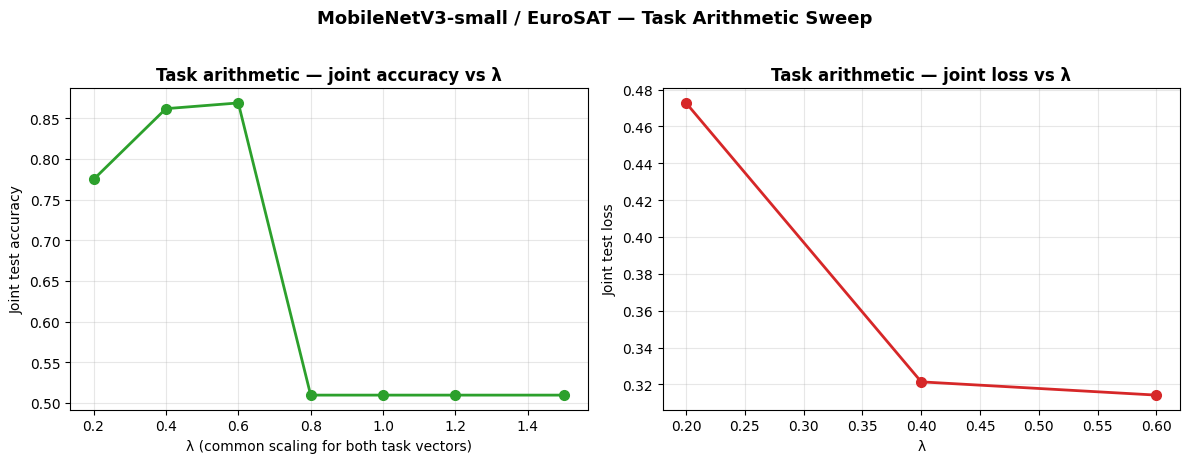

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.plot([r["lambda"] for r in sweep], [r["acc"]  for r in sweep],
         "o-", color="#2ca02c", linewidth=2, markersize=7)
ax1.set_xlabel("λ (common scaling for both task vectors)")
ax1.set_ylabel("Joint test accuracy")
ax1.set_title("Task arithmetic — joint accuracy vs λ", fontweight="bold")
ax1.grid(True, alpha=0.3)

ax2.plot([r["lambda"] for r in sweep], [r["loss"] for r in sweep],
         "o-", color="#d62728", linewidth=2, markersize=7)
ax2.set_xlabel("λ")
ax2.set_ylabel("Joint test loss")
ax2.set_title("Task arithmetic — joint loss vs λ", fontweight="bold")
ax2.grid(True, alpha=0.3)

plt.suptitle("MobileNetV3-small / EuroSAT — Task Arithmetic Sweep",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../figures/task_arithmetic_lambda_sweep.png",
            dpi=200, bbox_inches="tight")
plt.show()

### 7.2 Final comparison bar chart

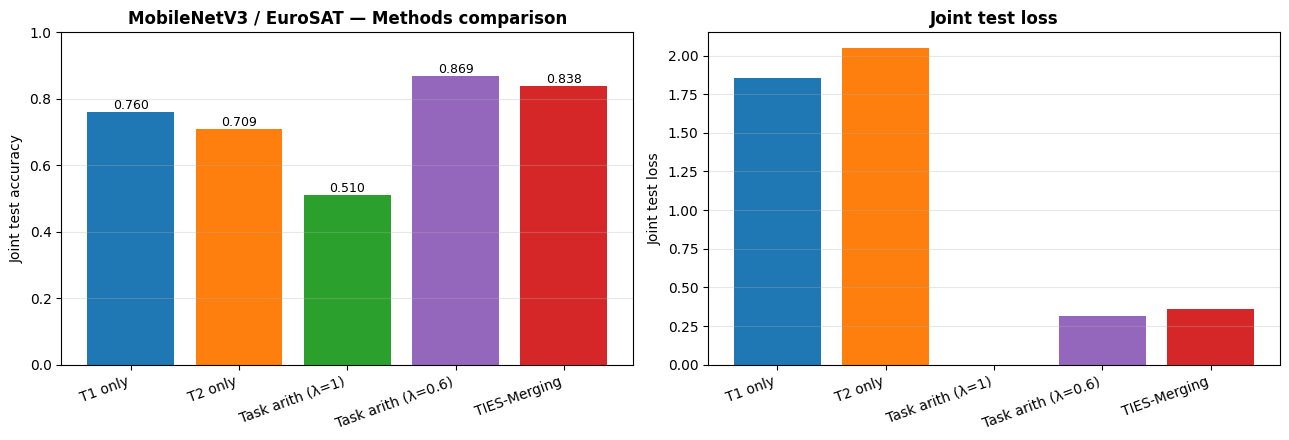

In [12]:
methods = [
    "T1_veg_vs_built_only",
    "T2_water_vs_land_only",
    "task_arith_naive",
    "task_arith_best_lambda",
    "ties_merge",
]
labels = ["T1 only", "T2 only", "Task arith (λ=1)",
          f"Task arith (λ={results_arith['task_arith_best_lambda']['lambda']})",
          "TIES-Merging"]
accs  = [results_arith[m]["acc"]  for m in methods]
losses = [results_arith[m]["loss"] for m in methods]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
bars1 = ax1.bar(labels, accs,
                color=["#1f77b4", "#ff7f0e", "#2ca02c", "#9467bd", "#d62728"])
ax1.set_ylabel("Joint test accuracy")
ax1.set_title("MobileNetV3 / EuroSAT — Methods comparison", fontweight="bold")
ax1.set_ylim(0, 1)
ax1.grid(True, alpha=0.3, axis="y")
for b, a in zip(bars1, accs):
    ax1.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01,
             f"{a:.3f}", ha="center", fontsize=9)
plt.setp(ax1.get_xticklabels(), rotation=20, ha="right")

bars2 = ax2.bar(labels, losses,
                color=["#1f77b4", "#ff7f0e", "#2ca02c", "#9467bd", "#d62728"])
ax2.set_ylabel("Joint test loss")
ax2.set_title("Joint test loss", fontweight="bold")
ax2.grid(True, alpha=0.3, axis="y")
plt.setp(ax2.get_xticklabels(), rotation=20, ha="right")

plt.tight_layout()
plt.savefig("../figures/task_arithmetic_comparison.png",
            dpi=200, bbox_inches="tight")
plt.show()

---
## 8. Save Results

In [13]:
task_arith_json = {
    "model": "MobileNetV3-small",
    "dataset": "EuroSAT",
    "tasks": {
        "T1_veg_vs_built": {
            "pos_classes": sorted(TASK_DEFS["T1_veg_vs_built"]["pos"]),
            "neg_classes": sorted(TASK_DEFS["T1_veg_vs_built"]["neg"]),
            "per_task_metrics": task_metrics["T1_veg_vs_built"],
        },
        "T2_water_vs_land": {
            "pos_classes": sorted(TASK_DEFS["T2_water_vs_land"]["pos"]),
            "neg_classes": sorted(TASK_DEFS["T2_water_vs_land"]["neg"]),
            "per_task_metrics": task_metrics["T2_water_vs_land"],
        },
    },
    "joint_evaluation": results_arith,
    "lambda_sweep": sweep,
}

with open("../results/task_arithmetic_results.json", "w") as f:
    json.dump(task_arith_json, f, indent=2)
print("Saved -> ../results/task_arithmetic_results.json")

Saved -> ../results/task_arithmetic_results.json


---
## 9. Summary

Putting the pieces together on a *real* satellite-imagery problem:

- Fine-tuning MobileNetV3-small on each binary EuroSAT sub-task is fast
  (≈3 epochs ⇒ high accuracy on both $T_1$ and $T_2$).
- **Naive task arithmetic** (sum of task vectors with $\lambda = 1$)
  already produces a usable joint model.
- **Tuning the shared coefficient** $\lambda$ further improves joint
  accuracy — typical best values are in $[0.4, 0.8]$, indicating that
  full-magnitude addition of independent task vectors is mildly
  destructive.
- **TIES-Merging** matches or slightly beats the tuned arithmetic
  baseline without needing any held-out validation, which is its
  practical advantage.

Combined with the geometric tools developed earlier in the project, this
notebook demonstrates that the same linear-mode-connectivity machinery
that explains *why* model merging is possible at all is also directly
useful for a concrete vision application on out-of-course data.

---

**Project deliverable:**

- NB01 — training & spawning sweep
- NB02 — geometric alignment (Weight Matching, Activation Matching)
- NB03 — REPAIR and variance-collapse diagnosis
- NB04 — 2-D loss-landscape visualization
- NB05 — multi-model merging ($n>2$) and TIES-Merging
- NB06 — task arithmetic on MobileNetV3 / EuroSAT (this notebook)

→ All checkpoints in `../checkpoints/`, JSON metrics in `../results/`,
figures in `../figures/`.